# ***Transformers vs. word2vec***

**Task:** Illustrate with diverse examples how Transformer encoder-generated embeddings capture context, in contrast to word2vec embeddings. Write a piece of code that illustrates the features and fundamental differences in how sequential data is represented


Note: Negative examples (where the model fails or behaves unexpectedly) are also welcome!

# **Setup**

In [1]:
!pip install -r requirements.txt
import re
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
%matplotlib inline

# **File preprocessing**

In [2]:
def preprocess_text(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read().lower()
    sentences = text.split('.')
    tokenized_sentences = [re.findall(r'\b\w+\b', sentence) for sentence in sentences if sentence]
    return text, tokenized_sentences

In [3]:
raw_text, tokenized = preprocess_text('data/pan_tadeusz.txt')

Continuous Bag of Words (CBOW): Predicts a target word based on its surrounding context words.

Skip-Gram: Predicts surrounding words given a target word.# **Word2Vec**

Word2vec is a technique in natural language processing for obtaining word as a high-dimension vector of numbers which capture relationships between words. In particular, words which appear in similar contexts are mapped to vectors which are nearby as measured by cosine similarity.

**Architectures:**

Continuous Bag of Words (CBOW): Predicts a target word based on its surrounding context words.

Skip-Gram: Predicts surrounding words given a target word.

In [4]:
model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, workers=4)
model.save("word2vec.model")

# **Transformer encoder**

# **Visualization**

In [5]:
def plot_3D(points_3d, labels):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')

    xs = points_3d[:, 0]
    ys = points_3d[:, 1]
    zs = points_3d[:, 2]

    ax.scatter(xs, ys, zs, marker='o', c='red', s=50)

    for i, label in enumerate(labels):
        ax.text(xs[i], ys[i], zs[i], label, size=10, zorder=1, color='k')

    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')

    plt.show()

# **Transformer encoder vs. word2vec**

In [6]:
word = 'czyli'

In [7]:
# to z docs testowalam jak dziala
vector = model.wv[word]  # get numpy vector of a word
sims = model.wv.most_similar(word, topn=10)  # get other similar words

In [8]:
similar_words_with_scores = model.wv.most_similar(word, topn=10)
words_to_plot = [word] + [word for word, score in similar_words_with_scores]
vectors = np.array([model.wv[word] for word in words_to_plot])

**Dimensionality reduction**

PCA is used to reduce the high-dimensional word vectors to 3D for visualization. The plot shows the target word and its most similar words based on cosine similarity in the original vector space.

In [9]:
pca_w2v = PCA(n_components=3)
vectors_3d = pca_w2v.fit_transform(vectors)

**Plot the results**

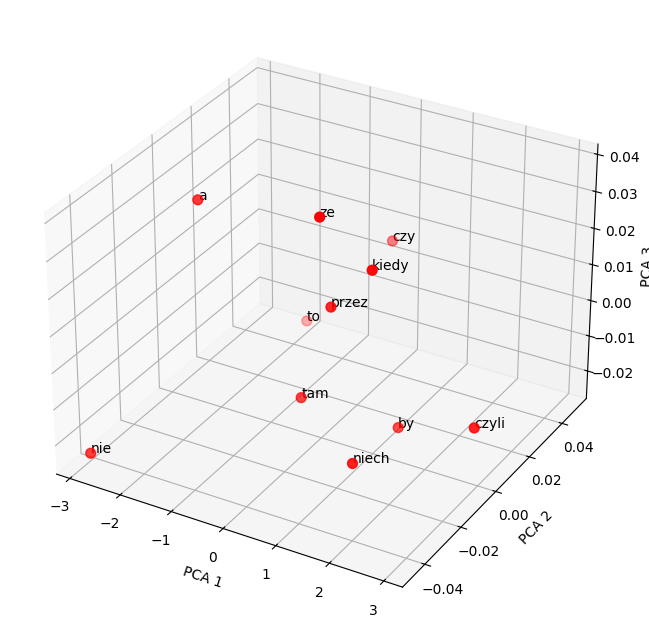

In [10]:
plot_3D(vectors_3d, words_to_plot)

# **Negative example - miniGPT decoder only**

# **References**

 Faculty of Fundamental Problems of Technology, Wrocław University of Science and Technology, Artificial intelligence 1 Modeling sequential data  - Lecture  nr 1.9A available via course portal (ePortal).

**Documentation:**

Word2Vec gensim documentation - https://radimrehurek.com/gensim/models/word2vec.html

**Additional reading**

Wikipedia, Word2vec — https://en.wikipedia.org/wiki/Word2vec

Understanding the Evolution of NLP: Word2Vec vs. Transformers - https://medium.com/@danhamdule74/understanding-the-evolution-of-nlp-word2vec-vs-transformers-7b7d5e38b4b0